## Imports and Functions

In [16]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns
import os
from pathlib import Path
import numpy as np
from pynwb import read_nwb
from matplotlib import pyplot as plt

from CSE583_humanSayMonkeyDo.load_config import load_config, get_config_value, get_data_paths
from CSE583_humanSayMonkeyDo.core import *


In [17]:

say_hello('hello')


'Hello, hello!'

## Using Data

In [18]:

#Get paths to monkey NWB files
monkey_paths = get_nwbs('monkey', 2)
#Load first NWB file
nwbfile = read_nwb(monkey_paths[0])
#Visualize entries
nwbfile


Data type,object
Shape,"(4,)"
Array size,32.00 bytes
Chunk shape,None
Compression,None
Compression opts,None
Uncompressed size (bytes),32
Compressed size (bytes),64
Compression ratio,0.5
Data type,float64
Shape,"(100516, 2)"


Index(['start_time', 'stop_time', 'target_on_time', 'go_cue_time', 'target_id',
       'target_corners', 'target_dir', 'result'],
      dtype='object')


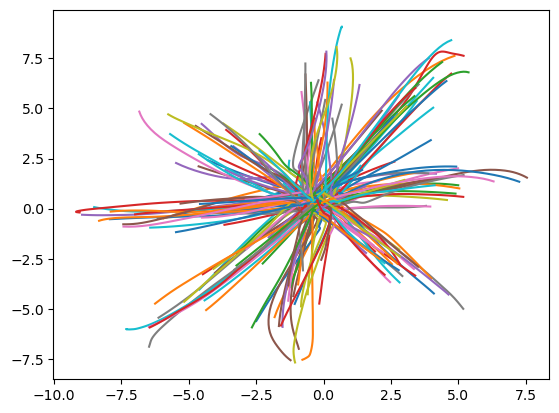

In [19]:
print(nwbfile.trials[:].keys())
# Lets view the data stored in the NWB file
cursor_pos = nwbfile.processing['behavior'].data_interfaces['Position'].spatial_series['cursor_pos']
go_cue_times = nwbfile.trials['go_cue_time'].data[:]
go_cue_times = go_cue_times[~np.isnan(go_cue_times)]  # Remove NaN values if any
window = [0.2, 0.5]  # 200 ms before to 500 ms after go cue

cursor_pos_chunks = get_windowed_pos_chunk(cursor_pos, go_cue_times, window)

for i, chunk in enumerate(cursor_pos_chunks):
    plt.plot(chunk[:,0],chunk[:,1])

In [20]:
list_units_spkts = nwbfile.units[:]['spike_times']

(220, 18, 71)
(18, 71)


(<Figure size 1200x800 with 2 Axes>,
 <Axes: title={'center': 'Neural Population Firing Rate'}, xlabel='Time Bin', ylabel='Unit Number'>)

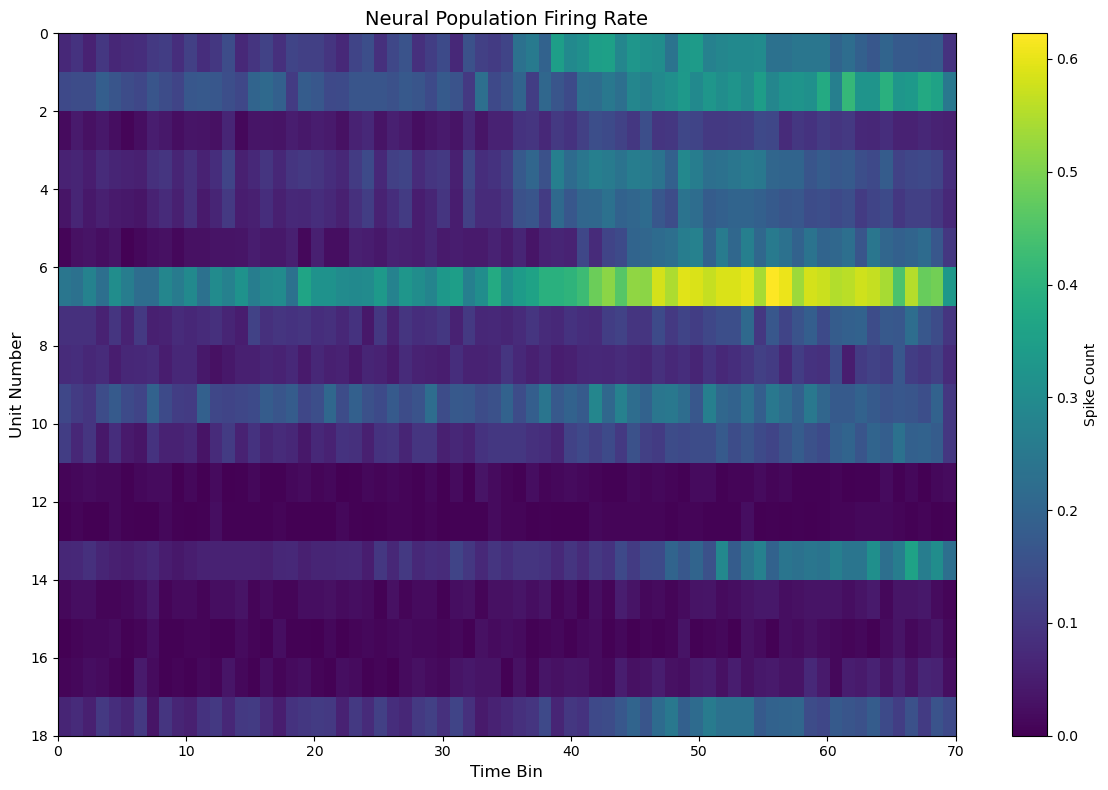

In [21]:
spike_data = get_chunk_spikes_binned_windowed(list_units_spkts, go_cue_times, window, bin_size=0.01)
print(spike_data[0].shape)
avg_spike_rates = np.mean(spike_data[0],axis=0)
print(avg_spike_rates.shape)


plot_firing_rate_heatmap(avg_spike_rates, time_axis=None, bin_size=None,
                              figsize=(12, 8), cmap='viridis', 
                              vmin=None, vmax=None, title=None)


## Movement Detection

In [22]:

cursor_vel = nwbfile.processing['behavior'].data_interfaces['Velocity'].time_series['cursor_vel']

# Usage
movement_times, movement_indices = get_movement_onset_times(
    cursor_vel, 
    go_cue_times, 
    threshold=5.0,
    window=[-0.1, 1.0]
)

# Filter out trials with no movement detected
valid_trials = ~np.isnan(movement_times)
print(f"Movement detected in {valid_trials.sum()}/{len(go_cue_times)} trials")
print(f"First movement onset at: {movement_times[valid_trials][0]:.3f} seconds")



Movement detected in 220/220 trials
First movement onset at: 5.930 seconds


In [23]:
window = [0.0, 0.2]
movement_spike_data = get_chunk_spikes_binned_windowed(list_units_spkts, movement_times[valid_trials], window, bin_size=0.01)



window = [0.2, 0.0]
stationary_spike_data = get_chunk_spikes_binned_windowed(list_units_spkts, go_cue_times[valid_trials], window, bin_size=0.01)

data = movement_spike_data[0]
move_category = np.ones(movement_spike_data[0].shape[0], dtype=int)  # All ones for movement


data = np.concatenate([data, stationary_spike_data[0]], axis=0)
move_category = np.concatenate([move_category,
                           np.zeros(stationary_spike_data[0].shape[0], dtype=int)])  # All zeros for stationary


print(move_category.shape)
print(data.shape)



(440,)
(440, 18, 21)


Data shape: (440, 378)
Labels shape: (440,)
Class distribution: 0=220, 1=220

=== LDA Classification Results ===
Training Accuracy: 1.000
Test Accuracy: 0.591
Cross-validation Accuracy: 0.595 (+/- 0.076)

CV Scores: [0.47727273 0.56818182 0.57954545 0.69318182 0.65909091]

=== Test Set Confusion Matrix ===
[[29 15]
 [21 23]]

=== Classification Report ===
              precision    recall  f1-score   support

     Class 0       0.58      0.66      0.62        44
     Class 1       0.61      0.52      0.56        44

    accuracy                           0.59        88
   macro avg       0.59      0.59      0.59        88
weighted avg       0.59      0.59      0.59        88



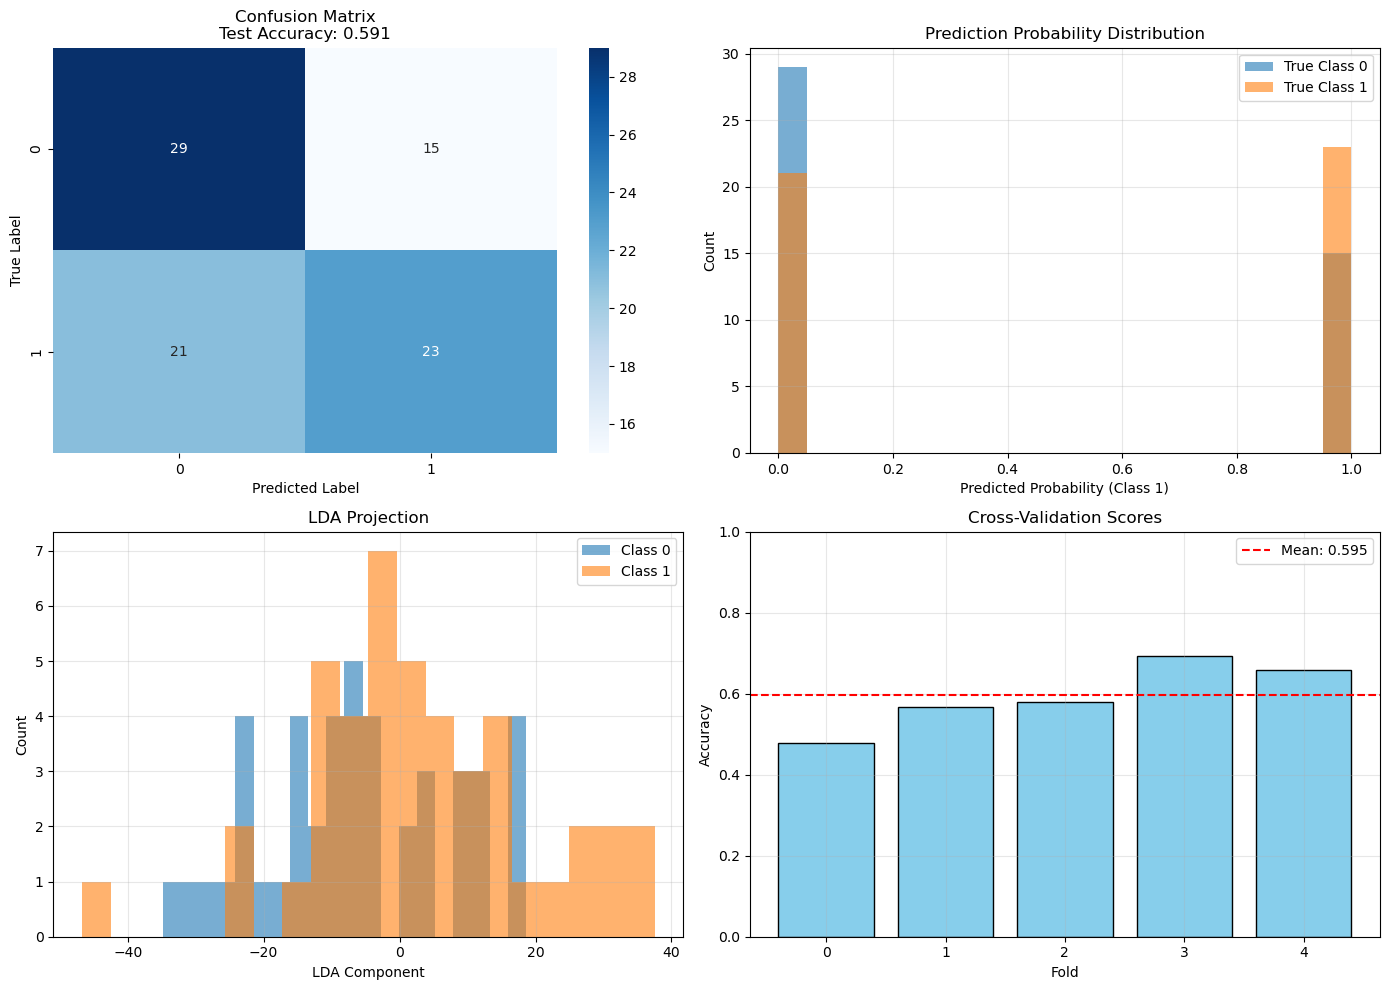

In [24]:



# Assuming you have:
# moving_spike_data: list of [18, 21] matrices for moving trials
# stationary_spike_data: list of [18, 21] matrices for stationary trials

# Combine data and create labels
#data_matrices = moving_spike_data + stationary_spike_data
#labels = np.concatenate([
#    np.ones(len(moving_spike_data), dtype=int),   # 1 for moving
#    np.zeros(len(stationary_spike_data), dtype=int)  # 0 for stationary
#])

# Train classifier
lda, results = train_lda_classifier(data, move_category)

# Visualize
plot_lda_results(results)